In [38]:
import pandas as pd
import numpy as np
from google.colab import drive
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, roc_auc_score
import seaborn as sns

# DATA LOADING AND EXPLORATION

In [39]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
df = pd.read_csv("/content/drive/MyDrive/Flexisaf_Internship/winequality.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.3,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.2,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Classify wines into two categories


* Class 0: Standard (Quality scores 3-6)

* Class 1: Premium (Quality scores 7-8)



In [41]:
df["quality"].unique()

array([5, 6, 7, 4, 8, 3, 2, 9])

In [42]:
df['is_good'] = (df['quality'] >= 7).astype(int)

In [43]:
df['is_good'].unique()

array([0, 1])

In [44]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1999 entries, 0 to 1998
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1999 non-null   float64
 1   volatile acidity      1999 non-null   float64
 2   citric acid           1999 non-null   float64
 3   residual sugar        1999 non-null   float64
 4   chlorides             1999 non-null   float64
 5   free sulfur dioxide   1999 non-null   float64
 6   total sulfur dioxide  1999 non-null   float64
 7   density               1999 non-null   float64
 8   pH                    1999 non-null   float64
 9   sulphates             1999 non-null   float64
 10  alcohol               1999 non-null   float64
 11  quality               1999 non-null   int64  
 12  is_good               1999 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 203.2 KB


In [46]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,is_good
count,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000
mean,8.670335,0.541773,0.246668,3.699090,0.075858,20.191096,52.617809,0.996477,3.290140,0.949465,10.671161,5.637819,0.192096
std,2.240023,0.180381,0.181348,3.290201,0.048373,15.642224,37.051121,0.002110,0.274297,0.780523,1.369932,1.255574,0.394047
min,4.600000,0.120000,0.000000,0.900000,0.010000,1.000000,6.000000,0.990070,2.340000,0.330000,8.400000,2.000000,0.000000
25%,7.100000,0.400000,0.110000,2.000000,0.056000,9.000000,24.000000,0.995265,3.180000,0.560000,9.500000,5.000000,0.000000
50%,8.000000,0.530000,0.200000,2.300000,0.075000,16.000000,42.000000,0.996600,3.300000,0.650000,10.400000,6.000000,0.000000
75%,9.900000,0.660000,0.385000,3.460000,0.086000,27.000000,73.000000,0.997800,3.420000,0.840000,11.400000,6.000000,0.000000
max,15.900000,1.580000,1.000000,15.990000,0.611000,72.000000,289.000000,1.003690,4.160000,3.990000,15.000000,9.000000,1.000000


## X-Input y-Output

In [47]:
X = df.drop(["quality", "is_good"], axis=1)
y = df["is_good"]

In [48]:
X.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')

In [49]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [50]:
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)


X_train : (1599, 11)
X_test : (400, 11)
y_train : (1599,)
y_test : (400,)


In [51]:
y_train.value_counts()

,count
is_good,
0,1284
1,315


In [52]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

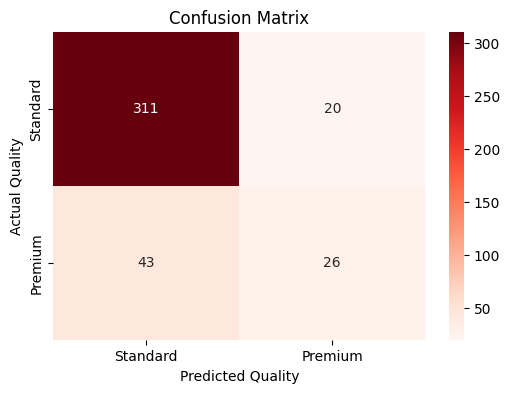


Classification Report:
              precision    recall  f1-score   support

Standard (0)       0.88      0.94      0.91       331
 Premium (1)       0.57      0.38      0.45        69

    accuracy                           0.84       400
   macro avg       0.72      0.66      0.68       400
weighted avg       0.82      0.84      0.83       400



In [53]:
# Confusion Matrix Visualization
def plot_confusion_matrix(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))

    # We use 2 labels: Standard (0) and Premium (1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=['Standard', 'Premium'],
                yticklabels=['Standard', 'Premium'])

    plt.title(f'Confusion Matrix')
    plt.ylabel('Actual Quality')
    plt.xlabel('Predicted Quality')
    plt.show()

plot_confusion_matrix(y_test, y_pred)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Standard (0)', 'Premium (1)']))



AUC: 0.865996759928193


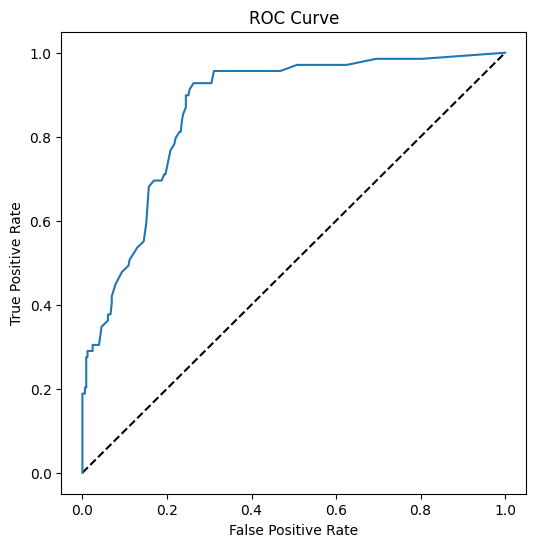

In [54]:

y_scores = rf.predict_proba(X_test)
auc = roc_auc_score(y_test,y_scores[:,1])
print('\nAUC: ' + str(auc))

# calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])

# plot ROC curve
fig = plt.figure(figsize=(6, 6))
# Plot the diagonal 50% line
plt.plot([0, 1], [0, 1], 'k--')
# Plot the FPR and TPR achieved by our model
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

### Using gradient boosting classifier

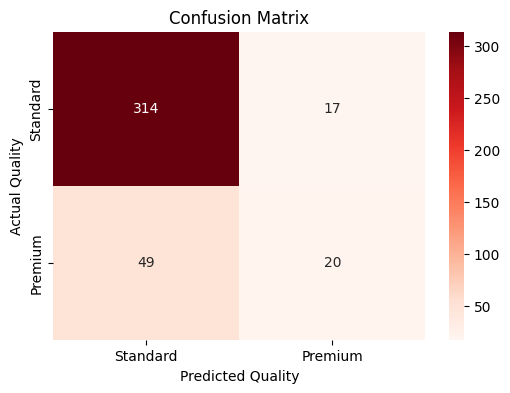


Classification Report:
              precision    recall  f1-score   support

Standard (0)       0.87      0.95      0.90       331
 Premium (1)       0.54      0.29      0.38        69

    accuracy                           0.83       400
   macro avg       0.70      0.62      0.64       400
weighted avg       0.81      0.83      0.81       400



In [55]:
GB = GradientBoostingClassifier(n_estimators=100, learning_rate = 0.1)
GB.fit(X_train, y_train)
y_pred = GB.predict(X_test)

plot_confusion_matrix(y_test, y_pred)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Standard (0)', 'Premium (1)']))



AUC: 0.8303778624283025


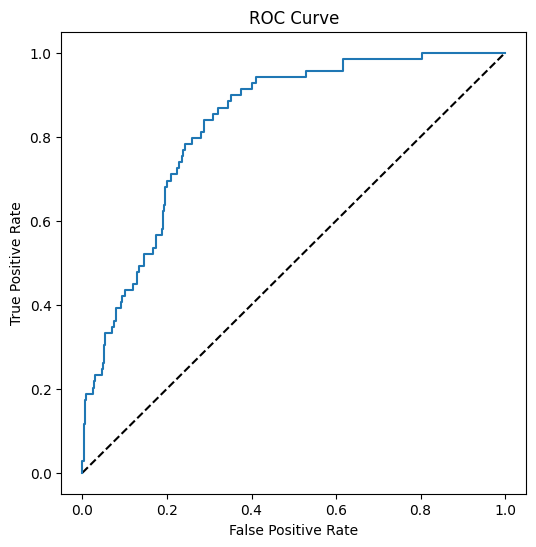

In [56]:
y_scores = GB.predict_proba(X_test)
auc = roc_auc_score(y_test,y_scores[:,1])
print('\nAUC: ' + str(auc))

# calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])

# plot ROC curve
fig = plt.figure(figsize=(6, 6))
# Plot the diagonal 50% line
plt.plot([0, 1], [0, 1], 'k--')
# Plot the FPR and TPR achieved by our model
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

# CREATING PIPELINE:
* Preprocessing
* Class balancing (SMOTE)
* model

 standard Scikit-Learn pipelines do not support SMOTE. Instead I use the pipeline from the imbalanced learn library.It is designed to handle Samplers like SMOTE alongside Scalers and Models.

In [57]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [58]:
rf_pipeline = Pipeline([('scaler', StandardScaler()),
 ('smote', SMOTE(random_state=42)),
  ('classifier', RandomForestClassifier(n_estimators=100))])

rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)

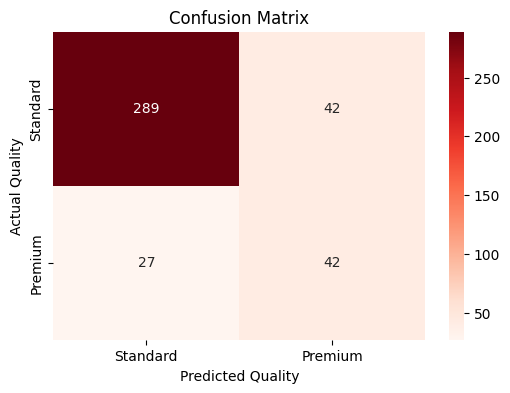


Classification Report:
              precision    recall  f1-score   support

Standard (0)       0.91      0.87      0.89       331
 Premium (1)       0.50      0.61      0.55        69

    accuracy                           0.83       400
   macro avg       0.71      0.74      0.72       400
weighted avg       0.84      0.83      0.83       400


AUC: 0.8605236656596174


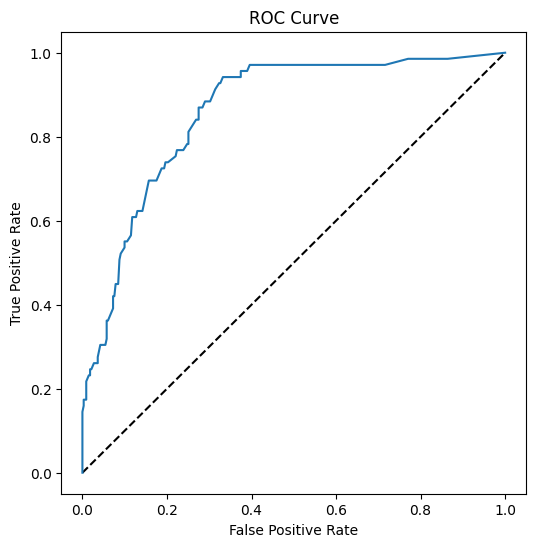

In [59]:
plot_confusion_matrix(y_test, y_pred)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Standard (0)', 'Premium (1)']))


y_scores = rf_pipeline.predict_proba(X_test)
auc = roc_auc_score(y_test,y_scores[:,1])
print('\nAUC: ' + str(auc))

# calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])

# plot ROC curve
fig = plt.figure(figsize=(6, 6))
# Plot the diagonal 50% line
plt.plot([0, 1], [0, 1], 'k--')
# Plot the FPR and TPR achieved by our model
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

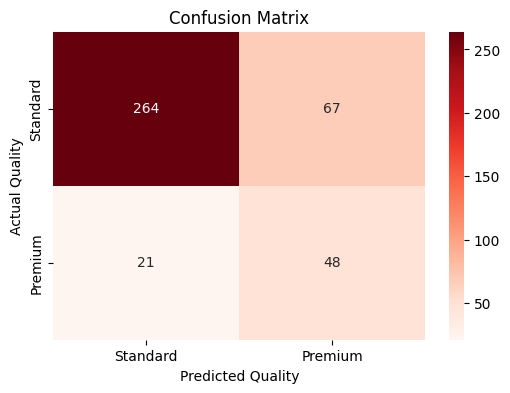


Classification Report:
              precision    recall  f1-score   support

Standard (0)       0.93      0.80      0.86       331
 Premium (1)       0.42      0.70      0.52        69

    accuracy                           0.78       400
   macro avg       0.67      0.75      0.69       400
weighted avg       0.84      0.78      0.80       400


AUC: 0.8344060598099742


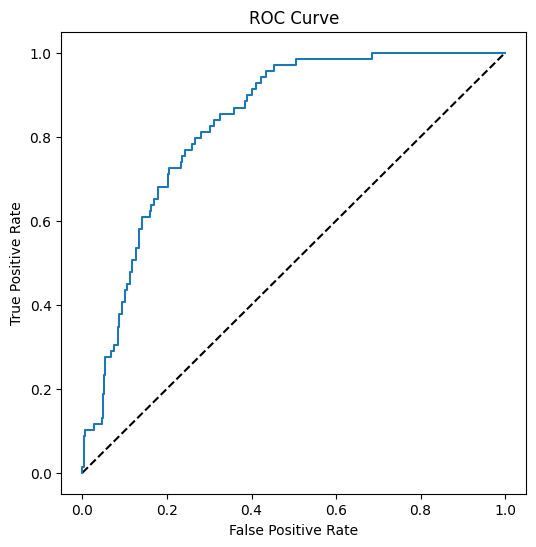

In [60]:
gb_pipeline = Pipeline([('scaler', StandardScaler()),
 ('smote', SMOTE(random_state=42)),
  ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate = 0.1))])

gb_pipeline.fit(X_train, y_train)
y_pred = gb_pipeline.predict(X_test)

plot_confusion_matrix(y_test, y_pred)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Standard (0)', 'Premium (1)']))


y_scores = gb_pipeline.predict_proba(X_test)
auc = roc_auc_score(y_test,y_scores[:,1])
print('\nAUC: ' + str(auc))

# calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])

# plot ROC curve
fig = plt.figure(figsize=(6, 6))
# Plot the diagonal 50% line
plt.plot([0, 1], [0, 1], 'k--')
# Plot the FPR and TPR achieved by our model
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [61]:
# USING XGBOOST

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    scale_pos_weight=4.8, # Heavily penalize missing a premium wine
    n_estimators=100,
    random_state=42
)

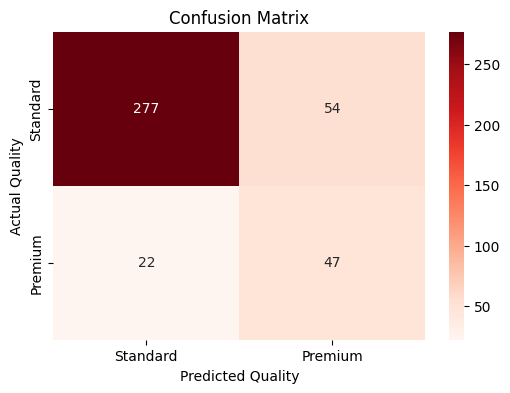


Classification Report:
              precision    recall  f1-score   support

Standard (0)       0.93      0.84      0.88       331
 Premium (1)       0.47      0.68      0.55        69

    accuracy                           0.81       400
   macro avg       0.70      0.76      0.72       400
weighted avg       0.85      0.81      0.82       400


AUC: 0.8382591181750515


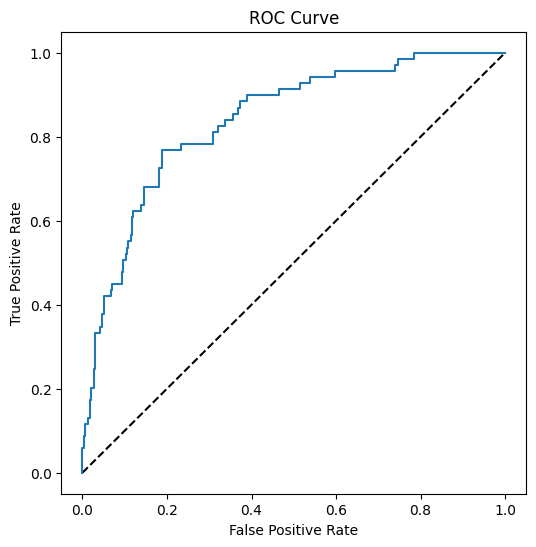

In [62]:
xg_pipeline = Pipeline([('scaler', StandardScaler()),
 ('smote', SMOTE(random_state=42)),
  ('classifier', xgb_model)])

xg_pipeline.fit(X_train, y_train)
y_pred = xg_pipeline.predict(X_test)

plot_confusion_matrix(y_test, y_pred)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Standard (0)', 'Premium (1)']))


y_scores = xg_pipeline.predict_proba(X_test)
auc = roc_auc_score(y_test,y_scores[:,1])
print('\nAUC: ' + str(auc))

# calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])

# plot ROC curve
fig = plt.figure(figsize=(6, 6))
# Plot the diagonal 50% line
plt.plot([0, 1], [0, 1], 'k--')
# Plot the FPR and TPR achieved by our model
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [63]:
xgb_tune = XGBClassifier(
    scale_pos_weight=6,
    learning_rate=0.01,
    n_estimators=500,
    max_depth=4,
    random_state=42)

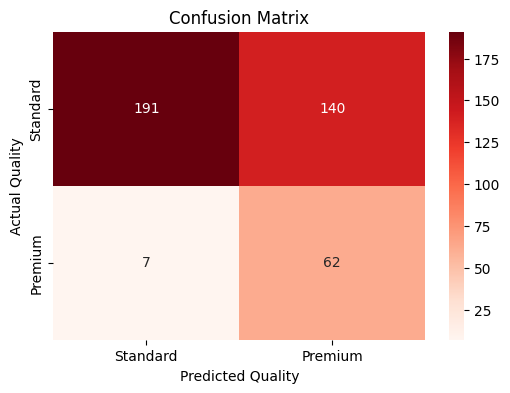


Classification Report (at 0.35 Threshold):
              precision    recall  f1-score   support

    Standard       0.96      0.58      0.72       331
     Premium       0.31      0.90      0.46        69

    accuracy                           0.63       400
   macro avg       0.64      0.74      0.59       400
weighted avg       0.85      0.63      0.68       400


AUC Score: 0.8376


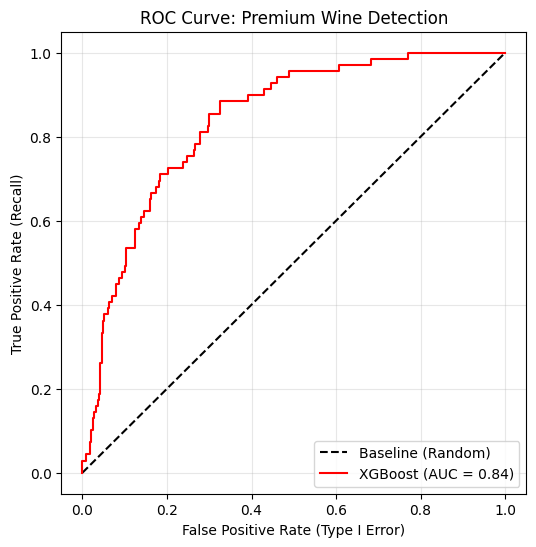

In [64]:
xg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', xgb_tune)
])

xg_pipeline.fit(X_train, y_train)

# 1. Get probabilities for the positive class (Premium)
y_scores = xg_pipeline.predict_proba(X_test)[:, 1]

# 2. Apply the custom threshold (0.35)
threshold = 0.35
y_pred_high_recall = (y_scores >= threshold).astype(int)

# 3. Calculate AUC using the probabilities
auc = roc_auc_score(y_test, y_scores)

# 4. PLOT: Use the high_recall predictions so the matrix matches the report
plot_confusion_matrix(y_test, y_pred_high_recall)

print("\nClassification Report (at 0.35 Threshold):")
print(classification_report(y_test, y_pred_high_recall, target_names=['Standard', 'Premium']))

print(f'\nAUC Score: {auc:.4f}')

# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Baseline (Random)')
plt.plot(fpr, tpr, color='red', label=f'XGBoost (AUC = {auc:.2f})')
plt.xlabel('False Positive Rate (Type I Error)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve: Premium Wine Detection')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# FEATURE IMPORTANCE

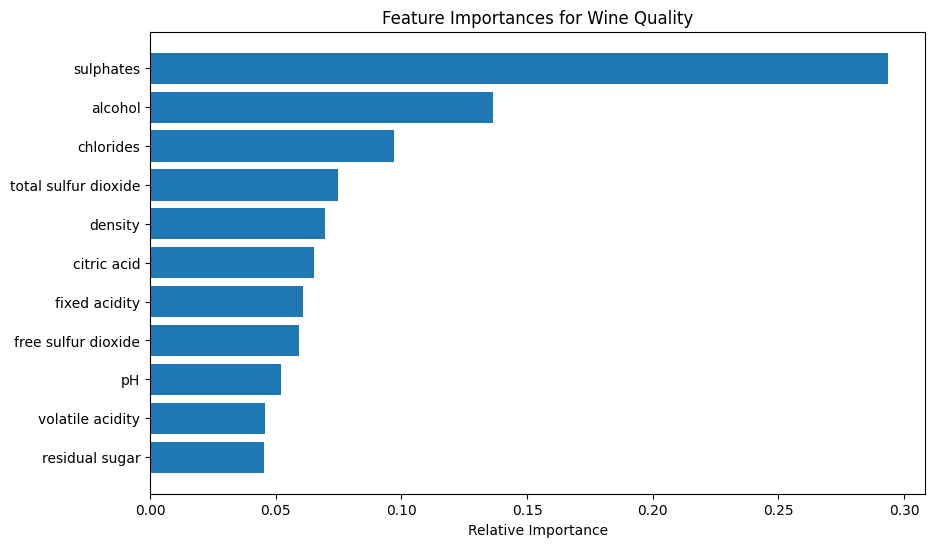

In [65]:
model = xg_pipeline.named_steps['classifier']

features = X.columns

importances = model.feature_importances_
indices = importances.argsort()

plt.figure(figsize=(10,6))
plt.title('Feature Importances for Wine Quality')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

### THE TASTE EXPERT LOGIC

I prioritized Recall (0.90) because the winery wants to ensure that no potentially Premium wine is accidentally sold as Standard. While the Precision is lower, a human sommelier can now focus their limited time on the wines flagged by the model, knowing they haven't missed the best batches.

# TRYING TO SEE IF I WILL GET A BETTER PERFORMANCE

Feature Engineering and Automated Hyperparameter Tuning.



### Feature Engineering (The "Acid-Sugar" Balance)

In winemaking, the balance between sweetness, acidity, and alcohol is what makes a "Premium" wine. You can create a few "Interaction Features" that help the model see patterns it might miss individually.

In [67]:
# Total Acidity: Combination of fixed and volatile acids
df['total_acidity'] = df['fixed acidity'] + df['volatile acidity']

# Sugar-to-Alcohol Ratio: A marker of fermentation quality
df['sugar_alc_ratio'] = df['residual sugar'] / df['alcohol']

# Bound Sulfur Dioxide: The difference between total and free
df['bound_sulfur_dioxide'] = df['total sulfur dioxide'] - df['free sulfur dioxide']


X1 = df.drop(['quality', 'is_good'], axis=1)
y1 = df["is_good"]
X1.columns

X1_train,X1_test,y1_train,y1_test = train_test_split(X1,y1, test_size = 0.20, random_state=42)

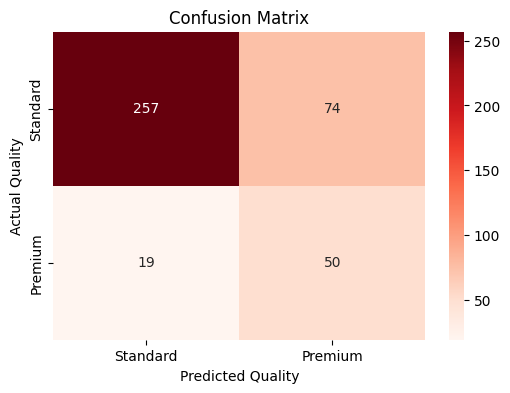


Classification Report:
              precision    recall  f1-score   support

Standard (0)       0.93      0.78      0.85       331
 Premium (1)       0.40      0.72      0.52        69

    accuracy                           0.77       400
   macro avg       0.67      0.75      0.68       400
weighted avg       0.84      0.77      0.79       400


AUC: 0.8473663470379614


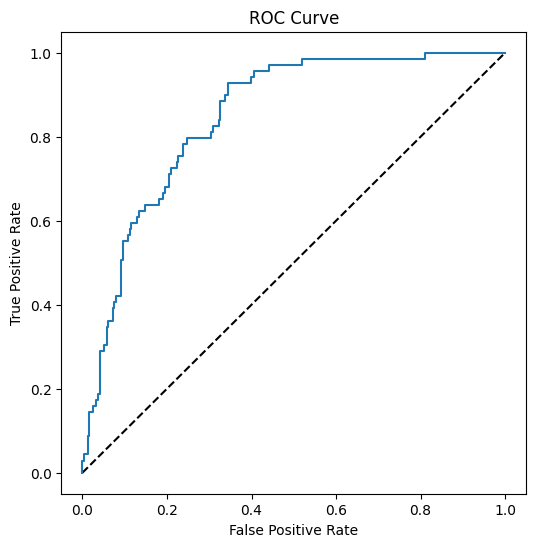

In [68]:
xgb_pipe = Pipeline([('scaler', StandardScaler()),
 ('smote', SMOTE(random_state=42)),
  ('classifier', XGBClassifier(learning_rate=0.01,
    n_estimators=500,
    max_depth=4,
    random_state=42))])

xgb_pipe.fit(X1_train, y1_train)
y1_pred = xgb_pipe.predict(X1_test)


plot_confusion_matrix(y1_test, y1_pred)
print("\nClassification Report:")
print(classification_report(y1_test, y1_pred, target_names=['Standard (0)', 'Premium (1)']))


y_scores = xgb_pipe.predict_proba(X1_test)
auc = roc_auc_score(y1_test,y_scores[:,1])
print('\nAUC: ' + str(auc))

# calculate ROC curve
fpr, tpr, thresholds = roc_curve(y1_test, y_scores[:,1])

# plot ROC curve
fig = plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--')

plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()


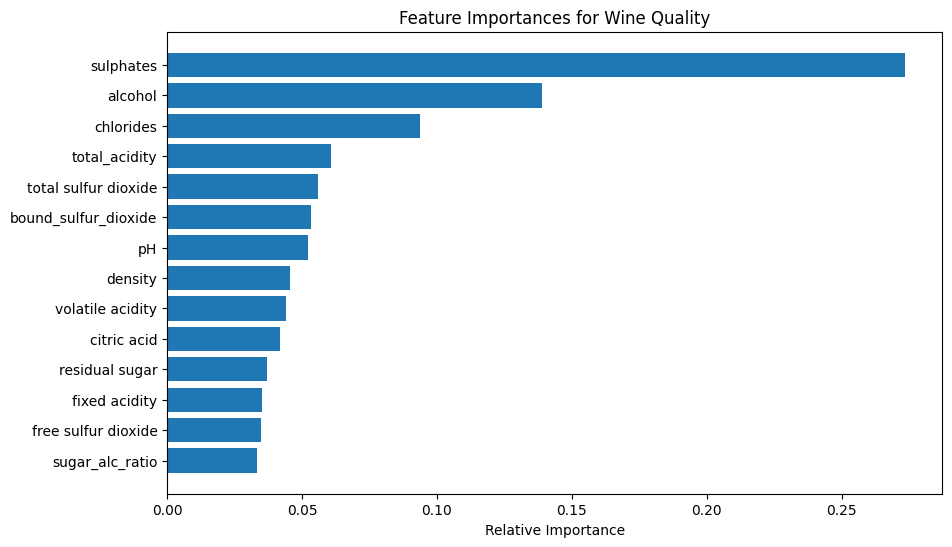

In [69]:
model = xgb_pipe.named_steps['classifier']

features = X1.columns

importances = model.feature_importances_
indices = importances.argsort()

plt.figure(figsize=(10,6))
plt.title('Feature Importances for Wine Quality')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## Hyperparameter Tuning (GridSearch)

Fitting 3 folds for each of 243 candidates, totalling 729 fits

Best Score (AUC): 0.8421
Best Params: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 7, 'classifier__n_estimators': 300, 'classifier__subsample': 0.9}

Final Classification Report with GridSearch Optimized Model:
              precision    recall  f1-score   support

    Standard       0.95      0.74      0.83       331
     Premium       0.39      0.80      0.52        69

    accuracy                           0.75       400
   macro avg       0.67      0.77      0.68       400
weighted avg       0.85      0.75      0.78       400



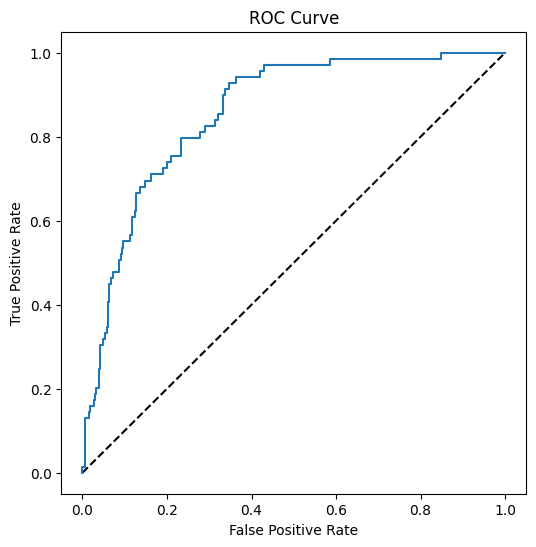

In [70]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__subsample': [0.7, 0.8, 0.9],
    'classifier__colsample_bytree': [0.7, 0.8, 0.9]
}

grid_search = GridSearchCV(
    xgb_pipe,
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"\nBest Score (AUC): {grid_search.best_score_:.4f}")
print(f"Best Params: {grid_search.best_params_}")


y_scores_best = best_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_scores_best >= 0.35).astype(int)

print("\nFinal Classification Report with GridSearch Optimized Model:")
print(classification_report(y_test, y_pred_final, target_names=['Standard', 'Premium']))

# calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores_best)

# plot ROC curve
fig = plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--')

plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [71]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression


base_models = [
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=200, learning_rate=0.05, random_state=42))
]

stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=5
)

stack_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', stack_model)
])

stack_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('classifier',
                 StackingClassifier(cv=5,
                                    estimators=[('rf',
                                                 RandomForestClassifier(n_estimators=200,
                                                                        random_state=42)),
                                                ('xgb',
                                                 XGBClassifier(base_score=None,
                                                               booster=None,
                                                               callbacks=None,
                                                               colsample_bylevel=None,
                                                               colsample_bynode=None,
                                                               colsample_bytree=None,
                                                               device=None,
                                                               early_stopping_...
                                                               importance_type=None,
                                                               interaction_constraints=None,
                                                               learning_rate=0.05,
                                                               max_bin=None,
                                                               max_cat_threshold=None,
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=None,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=200,
                                                               n_jobs=None,
                                                               num_parallel_tree=None, ...))],
                                    final_estimator=LogisticRegression()))])

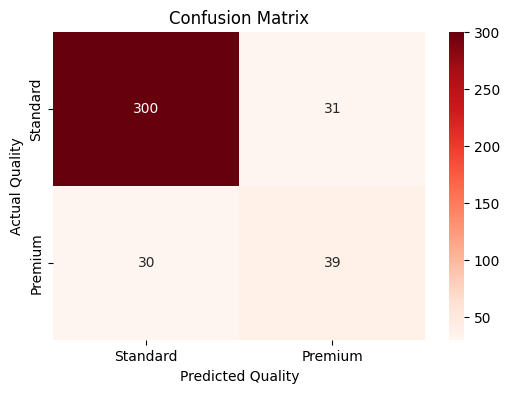


Classification Report:
              precision    recall  f1-score   support

Standard (0)       0.91      0.91      0.91       331
 Premium (1)       0.56      0.57      0.56        69

    accuracy                           0.85       400
   macro avg       0.73      0.74      0.73       400
weighted avg       0.85      0.85      0.85       400


AUC: 0.8684268137834407


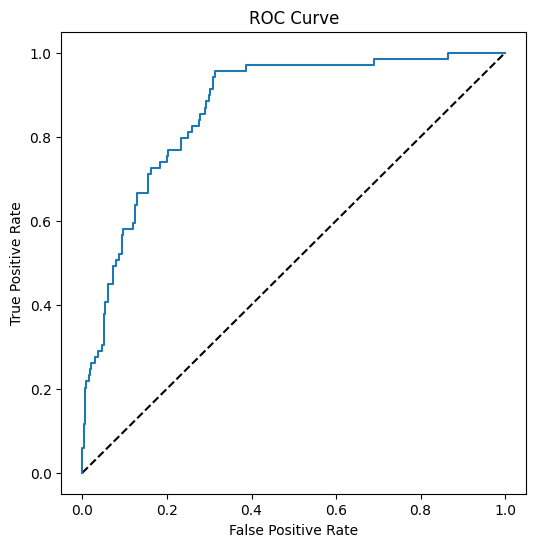

In [72]:
y_pred = stack_pipeline.predict(X_test)


plot_confusion_matrix(y_test, y_pred)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Standard (0)', 'Premium (1)']))


y_scores = stack_pipeline.predict_proba(X_test)
auc = roc_auc_score(y_test,y_scores[:,1])
print('\nAUC: ' + str(auc))

# calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])

# plot ROC curve
fig = plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--')

plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [73]:
filename = './stack_pipeline.pkl'
joblib.dump(stack_pipeline, filename)
print(f"Model saved successfully to {filename}")

Model saved successfully to ./stack_pipeline.pkl


# **Report: Wine Quality Classification Analysis**

### **Objective**
The goal was to apply ensemble learning methods (Random Forest, Gradient Boosting, and XGBoost) to classify wines into "Standard" and "Premium" categories based on chemical features. The final model used a Stacked Generalization approach to combine the strengths of these algorithms.

### **Dataset Distribution**
The evaluation was conducted on a test set of 400 samples, with a clear class imbalance:

Standard (Class 0): 331 samples (82.75%)

Premium (Class 1): 69 samples (17.25%)

### **Performance Evaluation**
Based on the final Stacked Model results, the performance metrics are as follows:

Overall Accuracy: 85%. While high, this is heavily influenced by the model's strong performance on the majority (Standard) class.

AUC (Area Under the Curve): 0.8684. This score indicates that the model has a high capability of distinguishing between the two classes regardless of the threshold.

### **Class-Specific Performance:**

* Standard Wines: The model is highly reliable, with a 0.91 F1-score, showing excellent precision and recall.

* Premium Wines: The model achieved a Precision of 0.56 and a Recall of 0.57. This means that when the model identifies a wine as Premium, it is correct approximately 56% of the time, and it successfully captures 57% of the total premium wines available in the dataset.

### **Technical Reflections**
Impact of Imbalance: Despite using SMOTE to balance the training data, the model still finds the "Premium" class more difficult to predict than the "Standard" class. This is common in real-world datasets where high-quality samples are rare.

### **Model Complexity**
The Stacked Model provided the most stable results. However, the moderate F1-score (0.56) for the Premium class suggests that while the chemical features are helpful, there is still some overlap in the chemical profiles of standard and premium wines that makes perfect separation difficult.

### **Conclusion**
The model is a significant improvement over random guessing (which would only be correct ~17% of the time for premium wines). It serves as an effective preliminary screening tool for quality control. In a professional setting, this model could be used to flag potential premium batches for further expert tasting, thereby reducing the workload of human evaluators by filtering out the 91% of standard wines it correctly identifies.